### **TF-MoDISco Motifs - File Interrogation**

**<span style="color: darkred;">This is notebook 1/2 of the TF-MoDISco motif downstream analyses.</span>**

Motifs are generated using the _scripts/chrombpnet_pipeline/4_TFModisco.sh_ script

The following script includes:
- Looking into the structures of the outputs
- Generating named outputs for the TF-MoDISco results, which only provide MA IDs. This associated a readable TF name to the results.
- Extracting motif sequences identified in TF-MoDISco for input in the _5_MarginalFootprints.sh_ function.

All TF-MoDISco output files are available in:

_/scratch/prj/stem_cells_pituitary/Georgia/ChromBPNet/outputs/(cohort)/(name)/tf_modisco/_

In [49]:
# Libraries
import h5py
import hdf5plugin
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import glob

### <div style = 'background-color:PapayaWhip'> **File Structure**</div>

In [1]:
# Take example files
# Paths
Results_modisco="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/experiments/experiment_10_AtT20_PAX7/tf_modisco/experiment_10_AtT20_PAX7_100k_modisco_results.h5"
motifs_results="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/experiments/experiment_10_AtT20_PAX7/tf_modisco/experiment_10_AtT20_PAX7_100k_modisco_report/motifs.html"

In [4]:
# Reading the h5 results file

with h5py.File(Results_modisco, 'r') as file:
    print("Keys: %s" % list(file.keys()))
    
    for key in file.keys():
        print(f"Inspecting group: {key}")
    print(file[key])

Keys: ['neg_patterns', 'pos_patterns']
Inspecting group: neg_patterns
Inspecting group: pos_patterns
<HDF5 group "/pos_patterns" (42 members)>


In [9]:
# Look into the pos_patterns 

with h5py.File(Results_modisco, 'r') as file:
    # See top level
    print("Top level:", list(file.keys()))
    
    # Pick a group and see what's inside
    group_name = 'pos_patterns'
    print(f"Inside {group_name}:", list(file[group_name].keys()))
    
    # Pick a specific pattern and see its datasets
    pattern_name = 'pattern_0'
    print(f"Inside {pattern_name}:", list(file[group_name][pattern_name].keys()))
    
    # Look into the datasets, only one can be selected from the below
    seqlet='seqlets'
    print(f"Inside {seqlet}:", list(file[group_name][pattern_name][seqlet].keys()))
    #starts='start'
    #print(f"Inside {start}:", list(file[group_name][pattern_name][seqlet][start]))

Top level: ['neg_patterns', 'pos_patterns']
Inside pos_patterns: ['pattern_0', 'pattern_1', 'pattern_10', 'pattern_11', 'pattern_12', 'pattern_13', 'pattern_14', 'pattern_15', 'pattern_16', 'pattern_17', 'pattern_18', 'pattern_19', 'pattern_2', 'pattern_20', 'pattern_21', 'pattern_22', 'pattern_23', 'pattern_24', 'pattern_25', 'pattern_26', 'pattern_27', 'pattern_28', 'pattern_29', 'pattern_3', 'pattern_30', 'pattern_31', 'pattern_32', 'pattern_33', 'pattern_34', 'pattern_35', 'pattern_36', 'pattern_37', 'pattern_38', 'pattern_39', 'pattern_4', 'pattern_40', 'pattern_41', 'pattern_5', 'pattern_6', 'pattern_7', 'pattern_8', 'pattern_9']
Inside pattern_0: ['contrib_scores', 'hypothetical_contribs', 'seqlets', 'sequence', 'subpattern_0', 'subpattern_1', 'subpattern_10', 'subpattern_11', 'subpattern_12', 'subpattern_13', 'subpattern_14', 'subpattern_2', 'subpattern_3', 'subpattern_4', 'subpattern_5', 'subpattern_6', 'subpattern_7', 'subpattern_8', 'subpattern_9']
Inside seqlets: ['contrib_

In [12]:
# Show the file format - how long the patterns are

with h5py.File(Results_modisco, 'r') as file:
    pos_patterns = file['pos_patterns']
    
    # Look at the first motif
    for motif in range(1):
        pattern_name = f'pattern_{motif}'
        if pattern_name in pos_patterns:
            group = pos_patterns[pattern_name]
            
            contrib_scores = group['contrib_scores'][:]
            sequence = group['sequence'][:]
            
            print(f"{pattern_name} information:")
            print(f"Sequence Shape: {sequence.shape}")
            print(f"Contribution Scores Shape: {contrib_scores.shape}")

pattern_0 information:
Sequence Shape: (30, 4)
Contribution Scores Shape: (30, 4)


In [14]:
# Look at the motifs.html file
#motifs_results="/scratch/prj/stem_cells_pituitary/Georgia/bpnet/exp26_ChIPseq_SOX2/exp26_SOX2_modisco_report/motifs.html"

table = pd.read_html(motifs_results)
df = table[0]
df.head(5)

,pattern,num_seqlets,modisco_cwm_fwd,modisco_cwm_rev,match0,qval0,match0_logo,match1,qval1,match1_logo,match2,qval2,match2_logo
0,pos_patterns.pattern_0,7585,NaN,NaN,MA1966.1,1.011770e-02,NaN,MA0522.1,1.011770e-02,NaN,MA1941.1,1.011770e-02,NaN
1,pos_patterns.pattern_1,6446,NaN,NaN,MA2681.1,1.360690e-05,NaN,MA0079.3,7.102380e-04,NaN,MA0599.1,1.741890e-03,NaN
2,pos_patterns.pattern_2,5094,NaN,NaN,MA0139.2,2.230600e-13,NaN,MA0139.1,2.602360e-13,NaN,MA1929.2,4.089430e-13,NaN
3,pos_patterns.pattern_3,3770,NaN,NaN,MA1528.1,6.065680e-05,NaN,MA1528.2,6.065680e-05,NaN,MA1527.2,6.065680e-05,NaN
4,pos_patterns.pattern_4,3251,NaN,NaN,MA1528.1,4.340340e-03,NaN,MA1527.1,4.340340e-03,NaN,MA1528.2,1.423150e-02,NaN


### <div style = 'background-color:PapayaWhip'> **Generate _named_ Output Files**</div>

In [21]:
# Load in target files
# Paths

Results_modisco="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/experiments/experiment_10_AtT20_PAX7/tf_modisco/experiment_10_AtT20_PAX7_100k_modisco_results.h5"
motifs_results="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/experiments/experiment_10_AtT20_PAX7/tf_modisco/experiment_10_AtT20_PAX7_100k_modisco_report/motifs.html"

In [22]:
# Look at the motifs.html file
table = pd.read_html(motifs_results)
df = table[0]
df.head(5)

,pattern,num_seqlets,modisco_cwm_fwd,modisco_cwm_rev,match0,qval0,match0_logo,match1,qval1,match1_logo,match2,qval2,match2_logo
0,pos_patterns.pattern_0,7585,NaN,NaN,MA1966.1,1.011770e-02,NaN,MA0522.1,1.011770e-02,NaN,MA1941.1,1.011770e-02,NaN
1,pos_patterns.pattern_1,6446,NaN,NaN,MA2681.1,1.360690e-05,NaN,MA0079.3,7.102380e-04,NaN,MA0599.1,1.741890e-03,NaN
2,pos_patterns.pattern_2,5094,NaN,NaN,MA0139.2,2.230600e-13,NaN,MA0139.1,2.602360e-13,NaN,MA1929.2,4.089430e-13,NaN
3,pos_patterns.pattern_3,3770,NaN,NaN,MA1528.1,6.065680e-05,NaN,MA1528.2,6.065680e-05,NaN,MA1527.2,6.065680e-05,NaN
4,pos_patterns.pattern_4,3251,NaN,NaN,MA1528.1,4.340340e-03,NaN,MA1527.1,4.340340e-03,NaN,MA1528.2,1.423150e-02,NaN


#### **Make new file with NAMED motifs to give biological clarity - one file only**

In [23]:
# Columns to keep 
# pattern - num_seqlets - match0 - qval0 - match1 - qval1 - match2 - qval2

cols_to_keep = ['pattern', 'num_seqlets', 'match0', 'qval0', 'match1', 'qval1', 'match2', 'qval2']
df_clean = df[cols_to_keep]
df_clean.head(5)

,pattern,num_seqlets,match0,qval0,match1,qval1,match2,qval2
0,pos_patterns.pattern_0,7585,MA1966.1,1.011770e-02,MA0522.1,1.011770e-02,MA1941.1,1.011770e-02
1,pos_patterns.pattern_1,6446,MA2681.1,1.360690e-05,MA0079.3,7.102380e-04,MA0599.1,1.741890e-03
2,pos_patterns.pattern_2,5094,MA0139.2,2.230600e-13,MA0139.1,2.602360e-13,MA1929.2,4.089430e-13
3,pos_patterns.pattern_3,3770,MA1528.1,6.065680e-05,MA1528.2,6.065680e-05,MA1527.2,6.065680e-05
4,pos_patterns.pattern_4,3251,MA1528.1,4.340340e-03,MA1527.1,4.340340e-03,MA1528.2,1.423150e-02


In [24]:
# Load JASPAR file to generate motif ID to name dictionary 

jaspar_2026="/scratch/prj/stem_cells_pituitary/Georgia/genome/JASPAR_CORE_2026_non-redundant.meme"

# Create a disctionary with key = ID and value = motif name
id_to_motif = {}

# Extract these names from the jaspar file
with open(jaspar_2026, 'r') as file:
    for line in file:
        if line.startswith("MOTIF"):
            parts = line.split()
            # parts[0] is the word MOTIF
            # parts[1] is the ID
            # parts[2] is the Motif name
            if len(parts) >= 3:
                id_to_motif[parts[1]] = parts[2]

print(f'Loaded {len(id_to_motif)} motif names for mapping')


Loaded 2059 motif names for mapping


In [25]:
# Add columns that align with TF motif names 
# New columns called: motif0, motif1, motif2

df_clean['motif0'] = df_clean['match0'].map(id_to_motif)
df_clean['motif1'] = df_clean['match1'].map(id_to_motif)
df_clean['motif2'] = df_clean['match2'].map(id_to_motif)

# Reorder columns
cols_order = ['pattern', 'num_seqlets', 'match0', 'motif0', 'qval0', 'match1', 
              'motif1', 'qval1', 'match2', 'motif2', 'qval2']

df_matched = df_clean[cols_order]
df_matched.head(10)

/tmp/ipykernel_4076313/826868947.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['motif0'] = df_clean['match0'].map(id_to_motif)
/tmp/ipykernel_4076313/826868947.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['motif1'] = df_clean['match1'].map(id_to_motif)
/tmp/ipykernel_4076313/826868947.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

,pattern,num_seqlets,match0,motif0,qval0,match1,motif1,qval1,match2,motif2,qval2
0,pos_patterns.pattern_0,7585,MA1966.1,TFAP4::ETV1,1.011770e-02,MA0522.1,Tcf3,1.011770e-02,MA1941.1,ETV2::FIGLA,1.011770e-02
1,pos_patterns.pattern_1,6446,MA2681.1,KLF8,1.360690e-05,MA0079.3,SP1,7.102380e-04,MA0599.1,KLF5,1.741890e-03
2,pos_patterns.pattern_2,5094,MA0139.2,CTCF,2.230600e-13,MA0139.1,CTCF,2.602360e-13,MA1929.2,CTCF,4.089430e-13
3,pos_patterns.pattern_3,3770,MA1528.1,NFIX,6.065680e-05,MA1528.2,NFIX,6.065680e-05,MA1527.2,NFIC,6.065680e-05
4,pos_patterns.pattern_4,3251,MA1528.1,NFIX,4.340340e-03,MA1527.1,NFIC,4.340340e-03,MA1528.2,NFIX,1.423150e-02
5,pos_patterns.pattern_5,2548,MA0076.3,ELK4,1.264270e-04,MA1483.3,ELF2,1.264270e-04,MA0750.3,ZBTB7A,1.264270e-04
6,pos_patterns.pattern_6,2460,MA0099.4,FOS::JUN,6.468120e-04,MA1128.2,FOSL1::JUN,6.468120e-04,MA1130.2,FOSL2::JUN,6.468120e-04
7,pos_patterns.pattern_7,2373,MA2546.1,ZNF131,5.165590e-03,MA2538.1,CGGBP1,2.900440e-02,MA0506.3,Nrf1,4.689350e-02
8,pos_patterns.pattern_8,2342,MA1644.1,NFYC,3.545770e-02,MA0060.1,NFYA,3.545770e-02,MA0060.3,NFYA,3.545770e-02
9,pos_patterns.pattern_9,1542,MA1546.2,PAX3,4.758530e-04,MA1546.1,PAX3,4.758530e-04,MA2094.1,PAX8,7.704500e-03


In [26]:
# Save as a .csv file
#output_csv = '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/experiments/experiment_10_AtT20_PAX7/tf_modisco/experiment_10_AtT20_PAX7_100k_modisco_results_named.csv'
#df_matched.to_csv(output_csv, index=False)

#### **Iterate through each .csv file**

Simplifies the process for similarly-generated files from cohorts or groups.

In [ ]:
# Iterate through the general files

cell_types=['Corticotrophs', 'Gonadotrophs', 'Gonadotrophs_Gata2_KO', 'Gonadotrophs_SF1_KO', 
            'Lactotrophs', 'Melanotrophs', 'Somatotrophs', 'Stem_cells', 'Thyrotrophs']

for cell in cell_types:
    
    print(f"Processing: {cell}")
    motif_html= f"/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/{cell}/tf_modisco/modisco_report/motifs.html"

    if not os.path.exists(motif_html):
        print(f"Skipping {cell}: File not found.")
        continue
    
    try:
        table = pd.read_html(motif_html)
        df = table[0]

        cols_to_keep = ['pattern', 'num_seqlets', 'match0', 'qval0', 'match1', 'qval1', 'match2', 'qval2']
        df_clean = df[cols_to_keep]
    
        df_clean['motif0'] = df_clean['match0'].map(id_to_motif)
        df_clean['motif1'] = df_clean['match1'].map(id_to_motif)
        df_clean['motif2'] = df_clean['match2'].map(id_to_motif)

        # Reorder columns
        cols_order = ['pattern', 'num_seqlets', 'match0', 'motif0', 'qval0', 'match1', 
                      'motif1', 'qval1', 'match2', 'motif2', 'qval2']

        df_matched = df_clean[cols_order]

        output_csv = f"/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/{cell}/tf_modisco/modisco_results_named.csv"
        df_matched.to_csv(output_csv, index=False)
    
    except Exception as e:
        print(f"Error processing {cell}: {e}")

print(f"Complete.")

In [28]:
# Link cell type to their respective "grouping" 
# Which was used to generate motifs based on a reduced list of relevant regions
cell_types=['Corticotrophs', 'Gonadotrophs', 'Gonadotrophs_Gata2_KO', 'Gonadotrophs_SF1_KO', 
            'Lactotrophs', 'Melanotrophs', 'Somatotrophs', 'Stem_cells', 'Thyrotrophs']
groupings=['grouping_4_down', 'grouping_2_up', 'grouping_2_up', 'grouping_2_up', 
           'grouping_6_up', 'grouping_4_up', 'grouping_7_up', 'grouping_1_up', 'grouping_8_up']
dictionary= dict(zip(cell_types, groupings))

dictionary

{'Corticotrophs': 'grouping_4_down',
 'Gonadotrophs': 'grouping_2_up',
 'Gonadotrophs_Gata2_KO': 'grouping_2_up',
 'Gonadotrophs_SF1_KO': 'grouping_2_up',
 'Lactotrophs': 'grouping_6_up',
 'Melanotrophs': 'grouping_4_up',
 'Somatotrophs': 'grouping_7_up',
 'Stem_cells': 'grouping_1_up',
 'Thyrotrophs': 'grouping_8_up'}

In [ ]:
# Iterate through the grouping files

#cell_types=['Corticotrophs', 'Gonadotrophs', 'Gonadotrophs_Gata2_KO', 'Gonadotrophs_SF1_KO', 
#            'Lactotrophs', 'Melanotrophs', 'Somatotrophs', 'Stem_cells', 'Thyrotrophs']
#groupings=['grouping_4_down', 'grouping_2_up', 'grouping_2_up', 'grouping_2_up', 
#           'grouping_6_up', 'grouping_4_up', 'grouping_7_up', 'grouping_1_up', 'grouping_8_up']
cell_types=['Lactotrophs']
groupings=['grouping_6_up']
dictionary= dict(zip(cell_types, groupings))

for cell in cell_types:
    
    print(f"Processing: {cell}")
    group=dictionary.get(cell)
    print(f"Group: {group}")
    
    motif_html= f"/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/{cell}/tf_modisco/{group}_modisco_report/motifs.html"

    if not os.path.exists(motif_html):
        print(f"Skipping {cell}: File not found.")
        continue
    
    try:
        table = pd.read_html(motif_html)
        df = table[0]

        cols_to_keep = ['pattern', 'num_seqlets', 'match0', 'qval0', 'match1', 'qval1', 'match2', 'qval2']
        df_clean = df[cols_to_keep]
    
        df_clean['motif0'] = df_clean['match0'].map(id_to_motif)
        df_clean['motif1'] = df_clean['match1'].map(id_to_motif)
        df_clean['motif2'] = df_clean['match2'].map(id_to_motif)

        # Reorder columns
        cols_order = ['pattern', 'num_seqlets', 'match0', 'motif0', 'qval0', 'match1', 
                      'motif1', 'qval1', 'match2', 'motif2', 'qval2']

        df_matched = df_clean[cols_order]

        output_csv = f"/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/{cell}/tf_modisco/{group}_modisco_results_named_try2.csv"
        df_matched.to_csv(output_csv, index=False)
    
    except Exception as e:
        print(f"Error processing {cell}: {e}")

print(f"Complete.")


### <div style = 'background-color:PapayaWhip'> **Extract sequences for Marginal Footprinting**</div>

#### **First look at files**

In [30]:
# Paths

Lactotrophs_modisco="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Lactotrophs/tf_modisco/modisco_results.h5"
motifs_results="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Lactotrophs/tf_modisco/modisco_report/motifs.html"

# Look into the pos_patterns 

with h5py.File(Lactotrophs_modisco, 'r') as file:
    # See top level
    print("Top level:", list(file.keys()))
    
    # Pick a group and see what's inside
    group_name = 'pos_patterns'
    #print(f"Inside {group_name}:", list(file[group_name].keys()))
    
    # Pick a specific pattern and see its datasets
    pattern_name = 'pattern_0'
    #print(f"Inside {pattern_name}:", list(file[group_name][pattern_name].keys()))
    
    seqlet='seqlets'
    #print(f"Inside {seqlet}:", list(file[group_name][pattern_name][seqlet].keys()))
    
    #starts='starts'
    #print(f"Inside {starts}:", list(file[group_name][pattern_name][seqlet][starts]))
    
    sequence='sequence'
    print(f"Inside {sequence}:", list(file[group_name][pattern_name][sequence]))

Top level: ['neg_patterns', 'pos_patterns']
Inside sequence: [array([0.22204258, 0.1301536 , 0.45028294, 0.19752088]), array([0.18674212, 0.23093506, 0.37078954, 0.21153328]), array([0.19455672, 0.24333064, 0.31150633, 0.25060631]), array([0.21827001, 0.41579089, 0.17569388, 0.19024522]), array([0.26704392, 0.19401778, 0.18620318, 0.35273511]), array([0.34114794, 0.30207491, 0.19078416, 0.16599299]), array([0.08191862, 0.28267313, 0.2462948 , 0.38911345]), array([0.4165993 , 0.08865535, 0.36324441, 0.13150094]), array([0.1048235 , 0.29533818, 0.51549448, 0.08434384]), array([0.04042037, 0.49366748, 0.0331447 , 0.43276745]), array([0.06979251, 0.02910267, 0.78119105, 0.11991377]), array([0.06952304, 0.8803557 , 0.02775532, 0.02236594]), array([0.00673673, 0.97844247, 0.00485044, 0.00997036]), array([0.36998114, 0.56831043, 0.02290488, 0.03880356]), array([0.00619779, 0.55241175, 0.00458098, 0.43680949]), array([0.00727567, 0.9746699 , 0.00673673, 0.0113177 ]), array([0.06601994, 0.05119

The motif sequence input needed for the Marginal Footprinting Command looks like this:

head motif_sequences.tsv 

MA0002.1	TATTGTGGTTA

MA0003.1	GCCCGGGGG

MA0004.1	CACGTG

MA0006.1	TGCGTG

MA0007.1	ATAAGAACACCCTGTACCCGCC

But realistically they can be called anything, no JASPAR name needed. 
1. Extract the sequence from the .h5 file
2. Write a .tsv file per TF Modisco output for each. 
3. Extract the names of the sequences (e.g., pos.patterns.pattern_0) and their associated num_seqlets and qval0 value (the qval value is representative of how likely the pattern is to being a JASPAR-named 2026 TF)
4. Subset for qval0 values that are larger than p>0.05 for significance reasons

**Code must first be run on the HPC**

**modisco-lite will make a meme file for each output .h5 file**

**From this, we can use the same code we used to make the motif_sequences list from the JASPAR file**

**Code for the HPC**

First make a .meme file for the results instead of an .h5

https://github.com/kundajelab/tfmodisco/blob/4e08ff1721d5c5efcc118b62be207b21a60fdb4d/examples/ModiscoDemonstration.ipynb#L1964

**Example**

/scratch/users/k25055720/conda_envs/bpnet_lite/bin/modisco meme \
  -i grouping_1_up_1000000_modisco_results.h5 \
  -t hCWM-PFM \
  -o grouping_1_up_1000000_modisco_results.hCWM-PFM.meme


#### **1+2. Extract the sequences from the .h5 file and write a .tsv file per TF modisco output.**

In [36]:
# Paths
tfmodisco_seqs="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Stem_cells/tf_modisco/grouping_1_up_1000000_modisco_results.hCWM-PFM.meme"
output_tsv="/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/tf_modisco_seqs/Stem_cells_grouping_1_up_1000000_modisco_results.tsv"

os.path.exists(tfmodisco_seqs)

True

In [ ]:
# This generates an output tsv file with the entire sequence as predicted by tfmodisco 
nucleotides = ['A', 'C', 'G', 'T']

print("Begin parsing MEME file.")

with open(tfmodisco_seqs, "r") as infile, open(output_tsv, "w") as outfile:
    current_id = None
    matrix_lines = []
    is_reading_matrix = False

    for line in infile:
        line = line.strip()
        
        # Identify the start of a motif
        if line.startswith("MOTIF"):
            # End sequence of previous motif
            if current_id and matrix_lines:
                consensus = ""
                for row in matrix_lines:
                    probs = [float(x) for x in row.split()]
                    max_idx = probs.index(max(probs))
                    consensus += nucleotides[max_idx]
                outfile.write(f"{current_id}\t{consensus}\n")
            
            # Begin sequence of new motif
            parts = line.split()
            current_id = parts[1]
            matrix_lines = []
            is_reading_matrix = False
            
        # Identify the letter-probability matrix within the motif information
        elif line.startswith("letter-probability matrix"):
            is_reading_matrix = True
            continue
            
        # Extract the letter-probability matrix
        elif is_reading_matrix:
            if not line or line.startswith("URL"):
                is_reading_matrix = False
                continue
            matrix_lines.append(line)

    # Last motif in the file
    if current_id and matrix_lines:
        consensus = ""
        for row in matrix_lines:
            probs = [float(x) for x in row.split()]
            max_idx = probs.index(max(probs))
            consensus += nucleotides[max_idx]
        outfile.write(f"{current_id}\t{consensus}\n")

print(f"Successfully created {output_tsv}")

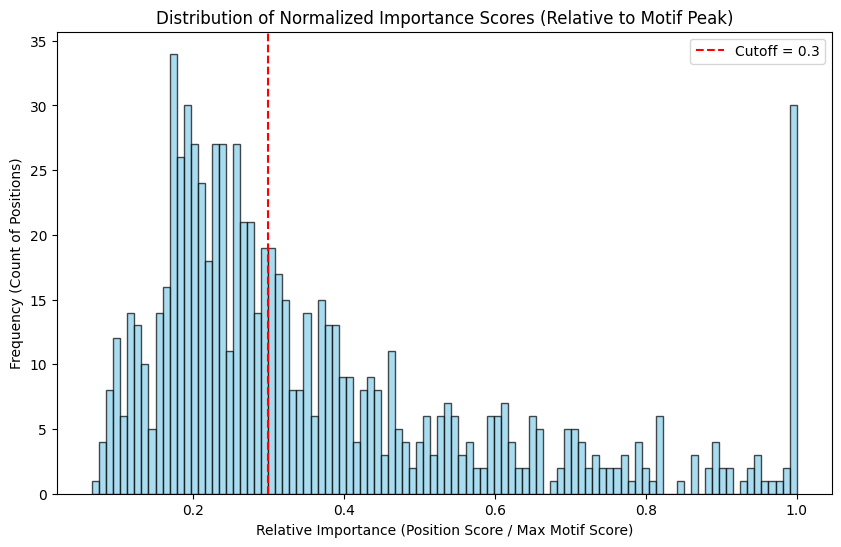

10th Percentile: 0.158
20th Percentile: 0.188
30th Percentile: 0.216
50th Percentile: 0.288


In [39]:
# Plot distribution of normalised hCWM scores
## For each position in each motif -> the hCWM importance score is calculated and then normalised relative to that motif's peak
## hCWM -> how important is that exact position. How much does the model care about that POSITION, regardless of what base is there. 

import matplotlib.pyplot as plt

tfmodisco_seqs = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Gonadotrophs/tf_modisco/grouping_2_up_1000000_modisco_results.h5"

all_norm_scores = []

with h5py.File(tfmodisco_seqs, "r") as f:
    for pattern_group in ['pos_patterns', 'neg_patterns']:
        if pattern_group not in f: continue
        for name, datasets in f[pattern_group].items():
            if not isinstance(datasets, h5py.Group): continue
            
            # Get the contribution scores
            cwm = datasets['hypothetical_contribs'][:]
            # Calculate importance per position
            score = np.sum(np.abs(cwm), axis=1)
            # Normalize by the maximum in that particular motif
            if np.max(score) > 0:
                norm_score = score / np.max(score)
                all_norm_scores.extend(norm_score)

# Plot the distribution 
plt.figure(figsize=(10, 6))
plt.hist(all_norm_scores, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0.3, color='red', linestyle='--', label='Cutoff = 0.3')
plt.title('Distribution of Normalized Importance Scores (Relative to Motif Peak)')
plt.xlabel('Relative Importance (Position Score / Max Motif Score)')
plt.ylabel('Frequency (Count of Positions)')
plt.legend()
plt.show()

# Print percentiles
percentiles = [10, 20, 30, 50]
p_values = np.percentile(all_norm_scores, percentiles)
for p, v in zip(percentiles, p_values):
    print(f"{p}th Percentile: {v:.3f}")

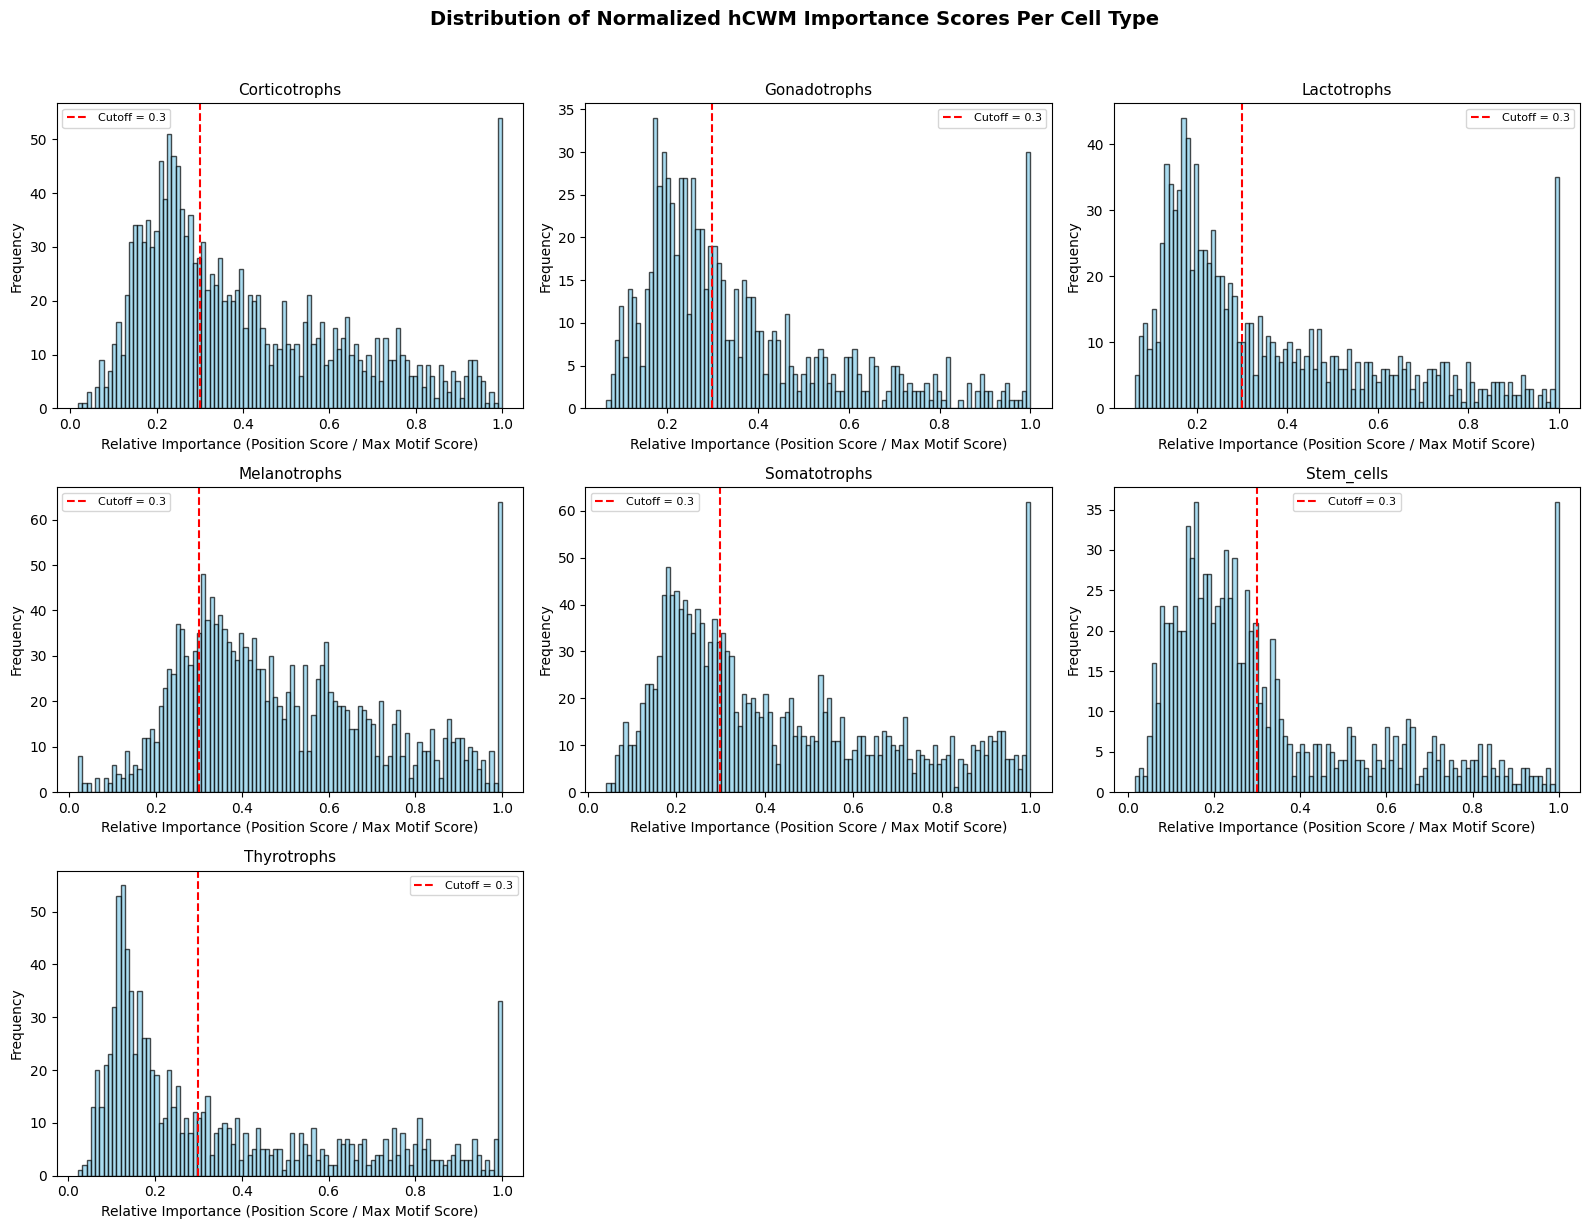

In [41]:
# Plot all distributions to see what a good cutoff is
base = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse"

files = {
    "Corticotrophs":  f"{base}/Corticotrophs/tf_modisco/grouping_4_down_modisco_results.h5",
    "Gonadotrophs":   f"{base}/Gonadotrophs/tf_modisco/grouping_2_up_modisco_results.h5",
    "Lactotrophs":    f"{base}/Lactotrophs/tf_modisco/grouping_6_up_modisco_results.h5",
    "Melanotrophs":   f"{base}/Melanotrophs/tf_modisco/grouping_4_up_modisco_results.h5",
    "Somatotrophs":   f"{base}/Somatotrophs/tf_modisco/grouping_7_up_modisco_results.h5",
    "Stem_cells":     f"{base}/Stem_cells/tf_modisco/grouping_1_up_modisco_results.h5",
    "Thyrotrophs":    f"{base}/Thyrotrophs/tf_modisco/grouping_8_up_modisco_results.h5",
}

cutoff = 0.3

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax, (cell_type, filepath) in zip(axes, files.items()):
    all_norm_scores = []
    with h5py.File(filepath, "r") as f:
        for pattern_group in ['pos_patterns', 'neg_patterns']:
            if pattern_group not in f:
                continue
            for name, datasets in f[pattern_group].items():
                if not isinstance(datasets, h5py.Group):
                    continue
                cwm = datasets['hypothetical_contribs'][:]
                score = np.sum(np.abs(cwm), axis=1)
                if np.max(score) > 0:
                    norm_score = score / np.max(score)
                    all_norm_scores.extend(norm_score)

    ax.hist(all_norm_scores, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    ax.axvline(x=cutoff, color='red', linestyle='--', label=f'Cutoff = {cutoff}')
    ax.set_title(cell_type, fontsize=11)
    ax.set_xlabel('Relative Importance (Position Score / Max Motif Score)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

# Hide last 2 plots (unused)
for ax in axes[len(files):]:
    ax.set_visible(False)

plt.suptitle('Distribution of Normalized hCWM Importance Scores Per Cell Type',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [42]:
nucleotides = ['A', 'C', 'G', 'T']
trim_thresh_frac = 0.3 
tfmodisco_seqs = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Stem_cells/tf_modisco/grouping_1_up_1000000_modisco_results.h5"
output_tsv = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/tf_modisco_seqs/Stem_cells_grouping_1_up_1000000_modisco_results_0.3.tsv"

target_group = "pos_patterns"
target_id = "pattern_12"

print(f"Begin parsing h5 file.")

with h5py.File(tfmodisco_seqs, "r") as f, open(output_tsv, "w") as outfile:
    for pattern_group in ['pos_patterns', 'neg_patterns']:
        if pattern_group not in f:
            continue
            
        for name, datasets in f[pattern_group].items():
            if not isinstance(datasets, h5py.Group):
                continue
            
            # Take the data
            pwm = datasets['sequence'][:]
            cwm = datasets['hypothetical_contribs'][:]
            
            # Trim flanks based on hCWM importance score
            ## hCWM estimates what the importance score of that POSITION is, hypothetically with the 4 possible nucleotides
            ## Takes the strongest point of the motif and sets a cutoff (e.g., 30% of that max)
            # Calculate the importance 
            score = np.sum(np.abs(cwm), axis=1)
            max_val = np.max(score)
            trim_thresh = max_val * trim_thresh_frac
            # Identify the boundaries of where to trim
            pass_inds = np.where(score >= trim_thresh)[0]
            start, end = np.min(pass_inds), np.max(pass_inds)
            # Trim using these boundaries
            trimmed_pwm = pwm[start: end + 1]
            norm_pwm = trimmed_pwm / np.sum(trimmed_pwm, axis=1, keepdims=True)
            # Argmax selects the most important base for each position (creation of the final sequence)
            consensus = "".join(nucleotides[np.argmax(row)] for row in norm_pwm)

            # Example --> pos.pattern_12 is a nice example
            if pattern_group == target_group and name == target_id:
                print(f"- Example: {target_group}.{target_id} -")
                print(f"1. h5 file data:")
                print(f"   - Motif length: {len(score)}bp")
                print(f"   - Max hCWM Importance: {max_val:.4f}")
                print(f"   So the trimming cutoff will be for values 30% of that size")
                
                print(f"2. Trimming:")
                print(f"   - Cutoff Value: {trim_thresh:.4f}")
                print(f"   - First index >= cutoff: {start}")
                print(f"   - Last index >= cutoff: {end}")
                print(f"   - New Length: {len(trimmed_pwm)}bp")

                print(f"3. Determine final sequence (argmax):")
                # Show first 5 positions of the trimmed result
                for i in range(min(5, len(norm_pwm))):
                    row = norm_pwm[i]
                    winner = np.argmax(row)
                    prob_line = " | ".join([f"{nucleotides[j]}: {row[j]:.2f}" for j in range(4)])
                    print(f"   Pos {start+i:02d}: [{prob_line}] -> {nucleotides[winner]}")
                print(f"    -> Total = {len(trimmed_pwm)}bp")
                print(f"4. Final consensus sequence:")
                print(f"   {consensus}")

            # Save result to tsv
            outfile.write(f"{pattern_group}.{name}\t{consensus}\n")

print(f"Done processing patterns: {output_tsv}")

Begin parsing h5 file.
- Example: pos_patterns.pattern_12 -
1. h5 file data:
   - Motif length: 30bp
   - Max hCWM Importance: 0.0276
   So the trimming cutoff will be for values 30% of that size
2. Trimming:
   - Cutoff Value: 0.0083
   - First index >= cutoff: 4
   - Last index >= cutoff: 13
   - New Length: 10bp
3. Determine final sequence (argmax):
   Pos 04: [A: 0.04 | C: 0.04 | G: 0.63 | T: 0.29] -> G
   Pos 05: [A: 0.02 | C: 0.93 | G: 0.01 | T: 0.04] -> C
   Pos 06: [A: 0.01 | C: 0.96 | G: 0.00 | T: 0.03] -> C
   Pos 07: [A: 0.86 | C: 0.03 | G: 0.02 | T: 0.09] -> A
   Pos 08: [A: 0.10 | C: 0.05 | G: 0.79 | T: 0.06] -> G
    -> Total = 10bp
4. Final consensus sequence:
   GCCAGCTGGC
Done processing patterns: /scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/tf_modisco_seqs/Stem_cells_grouping_1_up_1000000_modisco_results_0.3.tsv


#### **3. Extract the sequence names from each output file**

In [43]:
# Extract the names of the sequences from the results named files

example_file = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Corticotrophs/tf_modisco/grouping_4_down_modisco_results_named.csv"

sequence_pattern_map = pd.read_csv(example_file)
sequence_pattern_map.head()

,pattern,num_seqlets,match0,motif0,qval0,match1,motif1,qval1,match2,motif2,qval2
0,pos_patterns.pattern_0,4524,MA0461.1,Atoh1,3.678600e-04,MA1467.2,Atoh1,8.652250e-04,MA1100.1,ASCL1,8.652250e-04
1,pos_patterns.pattern_1,4323,MA1118.1,SIX1,1.135930e-06,MA1119.1,SIX2,3.512510e-06,MA2001.1,Six4,3.512510e-06
2,pos_patterns.pattern_2,3517,MA0648.2,GSC,7.553320e-03,MA0682.3,PITX1,7.553320e-03,MA0714.2,PITX3,7.553320e-03
3,pos_patterns.pattern_3,3001,MA0804.2,TBX19,4.522240e-06,MA0804.1,TBX19,8.951670e-06,MA0009.2,TBXT,2.039510e-05
4,pos_patterns.pattern_4,2302,MA0139.2,CTCF,1.869840e-15,MA1929.1,CTCF,1.869840e-15,MA0139.1,CTCF,1.954690e-15


In [44]:
# As data frame
subset_sequence_info = sequence_pattern_map[["pattern", "num_seqlets", "qval0"]]
subset_sequence_info.head()

,pattern,num_seqlets,qval0
0,pos_patterns.pattern_0,4524,3.678600e-04
1,pos_patterns.pattern_1,4323,1.135930e-06
2,pos_patterns.pattern_2,3517,7.553320e-03
3,pos_patterns.pattern_3,3001,4.522240e-06
4,pos_patterns.pattern_4,2302,1.869840e-15


#### **4. Subset for qval0 values larger than p>0.05 for significance**

In [45]:
# Filter for values of non-significance
# qval0 > 0.05

sequence_nonsig = subset_sequence_info[subset_sequence_info["qval0"] > 0.05]
#sequence_nonsig

pattern_names_nonsig = set(sequence_nonsig['pattern'])
pattern_names_nonsig

{'neg_patterns.pattern_1',
 'neg_patterns.pattern_10',
 'neg_patterns.pattern_11',
 'neg_patterns.pattern_14',
 'neg_patterns.pattern_19',
 'neg_patterns.pattern_2',
 'neg_patterns.pattern_20',
 'neg_patterns.pattern_3',
 'neg_patterns.pattern_4',
 'neg_patterns.pattern_5',
 'neg_patterns.pattern_6',
 'neg_patterns.pattern_8',
 'pos_patterns.pattern_21',
 'pos_patterns.pattern_23',
 'pos_patterns.pattern_27'}

In [46]:
# Subset .tsv file that's been generated and make sequence file of just those nonsignificant
file_to_subset = pd.read_csv("/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/tf_modisco_seqs/Thyrotrophs_grouping_8_up_modisco_results_0.3.tsv", 
                     sep="\t", header=None, names=["pattern", "sequence"])
#file_to_subset

In [47]:
file_after_subset = file_to_subset[file_to_subset['pattern'].isin(pattern_names_nonsig)]
file_after_subset = file_after_subset[file_after_subset['pattern'].str.contains('pos_patterns')]

#file_after_subset.to_csv("/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/tf_modisco_seqs/Thyrotrophs_tfmodisco_nonsig.tsv", sep="\t", index=False, header=False)
file_after_subset

,pattern,sequence
14,pos_patterns.pattern_21,CAGCCAATCAGAA
16,pos_patterns.pattern_23,ATGTTTATTTA
20,pos_patterns.pattern_27,GTGACGCAAGC


#### **Group into one file to run MarginalFootprinting**

In [ ]:
# Files
file_paths = '/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/tf_modisco_seqs/*_tfmodisco_nonsig.tsv'
file = glob.glob(file_paths)

# Function 

all_nonsig_patterns = []

for file in files:
    # Get cell type name
    filename = os.path.basename(file)
    cell_type = filename.split('_')[0]
    
    # Add name to file
    df = pd.read_csv(file, sep='\t', header=None, names=['pattern', 'sequence'])
    df['pattern'] = cell_type + '.' + df['pattern']
    all_nonsig_patterns.append(df)

# Put all files together 
combined_df = pd.concat(all_nonsig_patterns, ignore_index=True)
#combined_df.to_csv('/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/tf_modisco_seqs/Mouse_TFModisco_nonsig.tsv', sep='\t', index=False, header=False)

**Turn results from Mouse_TFModisco_nonsig.tsv into meme format for motif analysis**

(Done on the HPC)

**Run TOMTOM on the file**

conda activate chrombpnet 

**Run on JASPAR 2026**

tomtom -o tomtom_JASPAR_results -thresh 0.5 -evalue Mouse_TFModisco_nonsig.meme ../../../genome/JASPAR_CORE_2026_non-redundant.meme

**Run on HOCOMOCO MOUSE V11**

https://hocomoco14.autosome.org/downloads_v14

tomtom -o tomtom_HOCOMOCO_results -thresh 0.5 -evalue Mouse_TFModisco_nonsig.meme ../../../genome/H14CORE_meme_format.meme

### <div style = 'background-color:PapayaWhip'> **Merge all identified motif .h5 files**</div>

**The TFModisco command generated a file called grouping_X_X_modisco_results.h5 file per cell type.**

**These motifs are what the function identified as the top motifs extracted from the specific groupings.**

**To be able to visualise these in the marginal footprinting, they need to be merged together and run in the marginal footprinting command as one, regardless of cell type.**

In [52]:
Lacto_modisco = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Lactotrophs/tf_modisco/grouping_6_up_modisco_results_named.csv"
Lacto_modisco

'/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse/Lactotrophs/tf_modisco/grouping_6_up_modisco_results_named.csv'

**Within this file: match0 = MA ID that is predicted to be the TF associated with that sequence presence**

In [53]:
df = pd.read_csv(Lacto_modisco)
print(df.head())

                  pattern  num_seqlets    match0      motif0     qval0  \
0  pos_patterns.pattern_0         4846  MA0790.1      POU4F1  0.142750   
1  pos_patterns.pattern_1         4220  MA0835.3       BATF3  0.000318   
2  pos_patterns.pattern_2         3272  MA0790.1      POU4F1  0.005070   
3  pos_patterns.pattern_3         3096  MA1467.2       Atoh1  0.000047   
4  pos_patterns.pattern_4         2708  MA0119.1  NFIC::TLX1  0.020852   

     match1   motif1     qval1    match2   motif2     qval2  
0  MA0791.1   POU4F3  0.142750  MA0683.1   POU4F2  0.176192  
1  MA1988.2     Atf3  0.000318  MA2486.1     Fosb  0.000318  
2  MA0791.1   POU4F3  0.005070  MA0791.2   POU4F3  0.005070  
3  MA1642.1  NEUROG2  0.000155  MA0668.2  Neurod2  0.000218  
4  MA1528.2     NFIX  0.020852  MA1528.1     NFIX  0.023387  


In [ ]:
# NO NEED TO RUN AGAIN - ALREADY DONE

# Extract match0 results and generate a .tsv file per cell type of JUST the MA IDs identified
base = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse"

files = [
    "Corticotrophs/tf_modisco/grouping_4_down_modisco_results_named.csv",
    "Melanotrophs/tf_modisco/grouping_4_up_modisco_results_named.csv",
    "Gonadotrophs/tf_modisco/grouping_2_up_modisco_results_named.csv",
    "Somatotrophs/tf_modisco/grouping_7_up_modisco_results_named.csv",
    "Gonadotrophs_Gata2_KO/tf_modisco/grouping_2_up_modisco_results_named.csv",
    "Stem_cells/tf_modisco/grouping_1_up_modisco_results_named.csv",
    "Gonadotrophs_SF1_KO/tf_modisco/grouping_2_up_modisco_results_named.csv",
    "Thyrotrophs/tf_modisco/grouping_8_up_modisco_results_named.csv",
    "Lactotrophs/tf_modisco/grouping_6_up_modisco_results_named.csv",
]

for rel_path in files:
    full_path = os.path.join(base, rel_path)
    
    # Extract grouping_X_X from filename, e.g. grouping_6_up
    fname = os.path.basename(full_path)
    match = re.search(r'(grouping_\d+_\w+)', fname)
    grouping_tag = match.group(1) if match else "grouping_unknown"
    
    # Output file goes in the same tf_modisco directory
    out_dir = os.path.dirname(full_path)
    out_file = os.path.join(out_dir, f"{grouping_tag}_TFModisco_list.tsv")
    
    # Read and extract
    df = pd.read_csv(full_path)
    match0_series = df[['match0']].drop_duplicates().reset_index(drop=True)
    
    match0_series.to_csv(out_file, sep='\t', index=False, header=False)
    print(f"Saved: {out_file}")

# Extract the files generated above and merge into one 

base = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/outputs/mouse"

## Collect all individual TFModisco list files
tsv_files = glob.glob(os.path.join(base, "*/tf_modisco/*_TFModisco_list.tsv"))

all_match0 = []
for f in tsv_files:
    series = pd.read_csv(f, header=None, sep='\t').squeeze()
    all_match0.append(series)

# Merge, deduplicate, and save
merged = pd.concat(all_match0).drop_duplicates().reset_index(drop=True)

merged_out = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/grouping_motifs_from_TFmodisco.tsv"
merged.to_csv(merged_out, sep='\t', index=False, header=False)
print(f"Merged {len(tsv_files)} files → {merged_out}  ({len(merged)} unique motifs)")

In [ ]:
# NO NEED TO RUN AGAIN - ALREADY DONE

# Associate the correct sequence pattern with each MA id within the file generated above

# Load the MA IDs from the TFModisco results
modisco_ids = pd.read_csv("/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/grouping_motifs_from_TFmodisco.tsv", header=None, sep='\t').squeeze().tolist()

# Load motif_sequences.tsv (no header, two columns: MA ID and sequence)
motif_seq = pd.read_csv("/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/motif_sequences.tsv", header=None, sep='\t', names=['ma_id', 'sequence'])

# Filter for matching MA IDs
filtered = motif_seq[motif_seq['ma_id'].isin(modisco_ids)]

# Save
out = "/scratch/prj/stem_cells_pituitary/Georgia/ChromBPnet/data/TFModisco_grouping_motifs.tsv"
filtered.to_csv(out, sep='\t', index=False, header=False)
print(f"Matched {len(filtered)} / {len(modisco_ids)} motifs")